# Customer Churn & Uplift Modeling
## 01 — Data Understanding

### Objective

The objective of this notebook is to understand the structure,
characteristics, treatment assignment, and outcomes of the dataset
before performing data preprocessing and machine learning.

We will investigate:

- Dataset size and structure
- Feature types
- Missing values
- Treatment and control groups
- Conversion and visit outcomes
- Basic statistical properties
- Initial relationships between treatment and outcomes

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [4]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Dataset size (MB):", round(DATA_PATH.stat().st_size / (1024 ** 2), 2))

Dataset path: C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz
Dataset exists: True
Dataset size (MB): 297.0


In [5]:
# Read only a small sample to understand the dataset structure

sample_df = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    nrows=10_000
)

print("Sample shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

Sample shape: (10000, 16)

Columns:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']


In [9]:
print("Number of columns:", len(sample_df.columns))

print("\nColumns:")
for i, column in enumerate(sample_df.columns, start=1):
    print(f"{i:2}. {column}")

Number of columns: 16

Columns:
 1. f0
 2. f1
 3. f2
 4. f3
 5. f4
 6. f5
 7. f6
 8. f7
 9. f8
10. f9
11. f10
12. f11
13. treatment
14. conversion
15. visit
16. exposure


In [10]:
print("Data types:")
print(sample_df.dtypes)

Data types:
f0            float64
f1            float64
f2            float64
f3            float64
f4            float64
f5            float64
f6            float64
f7            float64
f8            float64
f9            float64
f10           float64
f11           float64
treatment       int64
conversion      int64
visit           int64
exposure        int64
dtype: object


In [11]:
sample_df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.6164,10.0597,8.9764,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
1,12.6164,10.0597,9.0027,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
2,12.6164,10.0597,8.9648,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
3,12.6164,10.0597,9.0028,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
4,12.6164,10.0597,9.0380,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0


In [12]:
missing_values = sample_df.isnull().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": (
        missing_values / len(sample_df) * 100
    )
})

missing_summary

,missing_count,missing_percentage
f0,0,0.0000
f1,0,0.0000
f2,0,0.0000
f3,0,0.0000
f4,0,0.0000
f5,0,0.0000
f6,0,0.0000
f7,0,0.0000
f8,0,0.0000
f9,0,0.0000


In [13]:
print(
    "Total missing values:",
    int(missing_values.sum())
)

Total missing values: 0


In [14]:
sample_df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,10000.0000,21.2535,4.8403,12.6164,17.9954,22.7445,24.6275,26.7451
f1,10000.0000,10.0666,0.0877,10.0597,10.0597,10.0597,10.0597,13.5798
f2,10000.0000,8.3729,0.2820,8.2144,8.2144,8.2144,8.4128,9.0519
f3,10000.0000,4.3655,1.0976,-4.7984,4.6799,4.6799,4.6799,4.6799
f4,10000.0000,10.3575,0.4522,10.2805,10.2805,10.2805,10.2805,18.7223
f5,10000.0000,4.0368,0.4176,-5.7745,4.1155,4.1155,4.1155,4.1155
f6,10000.0000,-4.2951,4.1756,-24.0935,-6.6993,-3.2821,-1.2882,0.2944
f7,10000.0000,5.0814,1.1608,4.8338,4.8338,4.8338,4.8338,11.9937
f8,10000.0000,3.9538,0.0405,3.6823,3.9554,3.9719,3.9719,3.9719
f9,10000.0000,14.2557,4.3590,13.1901,13.1901,13.1901,13.1901,56.9446


In [15]:
total_rows = 0

for chunk in pd.read_csv(
    DATA_PATH,
    compression="gzip",
    chunksize=250_000
):
    total_rows += len(chunk)

print(f"Total dataset rows: {total_rows:,}")

Total dataset rows: 13,979,592


In [16]:
treatment_counts = sample_df["treatment"].value_counts().sort_index()

print("Treatment counts:")
print(treatment_counts)

print("\nTreatment percentages:")
print(
    (treatment_counts / len(sample_df) * 100).round(2)
)

Treatment counts:
treatment
1    10000
Name: count, dtype: int64

Treatment percentages:
treatment
1   100.0000
Name: count, dtype: float64


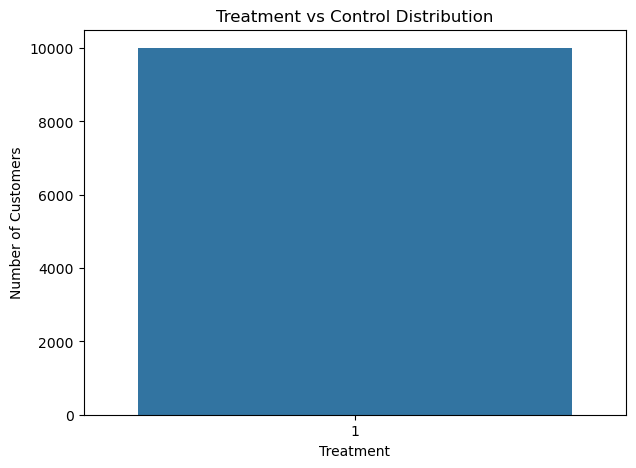

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=sample_df,
    x="treatment"
)

plt.title("Treatment vs Control Distribution")
plt.xlabel("Treatment")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
conversion_counts = sample_df["conversion"].value_counts().sort_index()

print("Conversion counts:")
print(conversion_counts)

print("\nConversion percentages:")
print(
    (conversion_counts / len(sample_df) * 100).round(4)
)

Conversion counts:
conversion
0    9953
1      47
Name: count, dtype: int64

Conversion percentages:
conversion
0   99.5300
1    0.4700
Name: count, dtype: float64


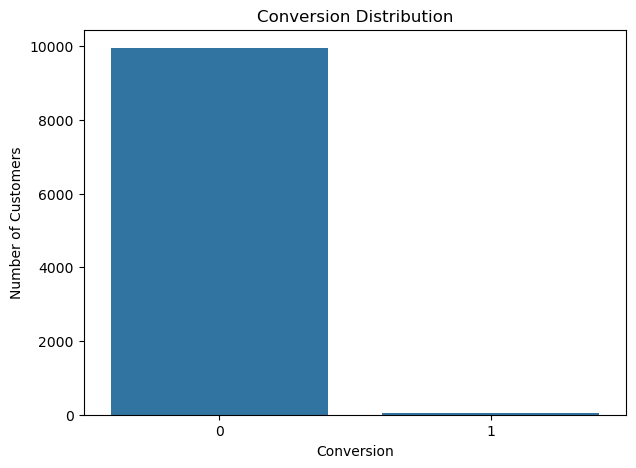

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=sample_df,
    x="conversion"
)

plt.title("Conversion Distribution")
plt.xlabel("Conversion")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
visit_counts = sample_df["visit"].value_counts().sort_index()

print("Visit counts:")
print(visit_counts)

print("\nVisit percentages:")
print(
    (visit_counts / len(sample_df) * 100).round(2)
)

Visit counts:
visit
0    9790
1     210
Name: count, dtype: int64

Visit percentages:
visit
0   97.9000
1    2.1000
Name: count, dtype: float64


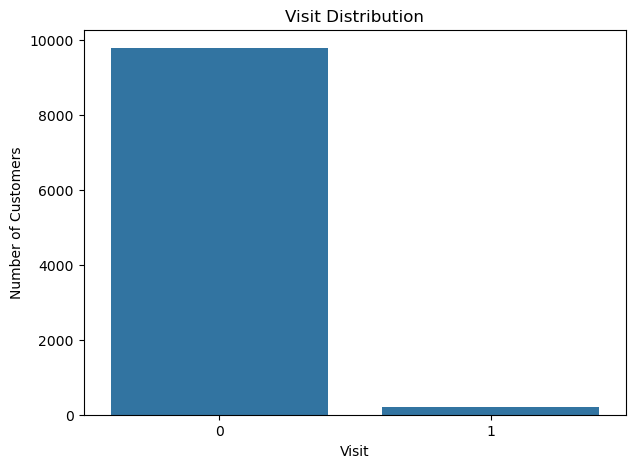

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=sample_df,
    x="visit"
)

plt.title("Visit Distribution")
plt.xlabel("Visit")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
exposure_counts = sample_df["exposure"].value_counts().sort_index()

print("Exposure counts:")
print(exposure_counts)

print("\nExposure percentages:")
print(
    (exposure_counts / len(sample_df) * 100).round(2)
)

Exposure counts:
exposure
0    9751
1     249
Name: count, dtype: int64

Exposure percentages:
exposure
0   97.5100
1    2.4900
Name: count, dtype: float64


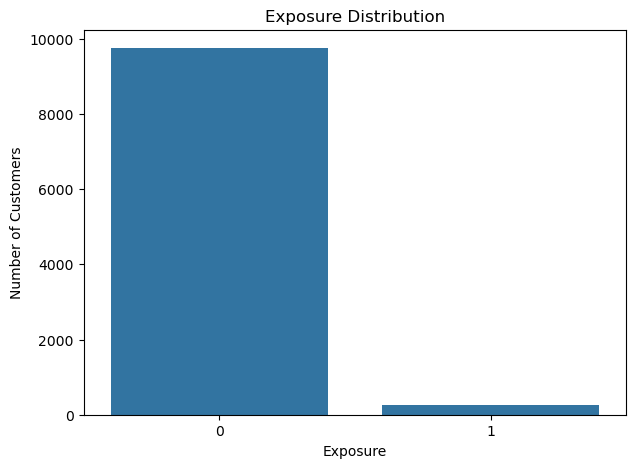

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=sample_df,
    x="exposure"
)

plt.title("Exposure Distribution")
plt.xlabel("Exposure")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
treatment_conversion = pd.crosstab(
    sample_df["treatment"],
    sample_df["conversion"]
)

treatment_conversion

conversion,0,1
treatment,,
1,9953,47


In [25]:
conversion_rate_by_treatment = (
    sample_df
    .groupby("treatment")["conversion"]
    .mean()
    .mul(100)
)

print("Conversion rate by treatment group:")
print(conversion_rate_by_treatment)

Conversion rate by treatment group:
treatment
1   0.4700
Name: conversion, dtype: float64


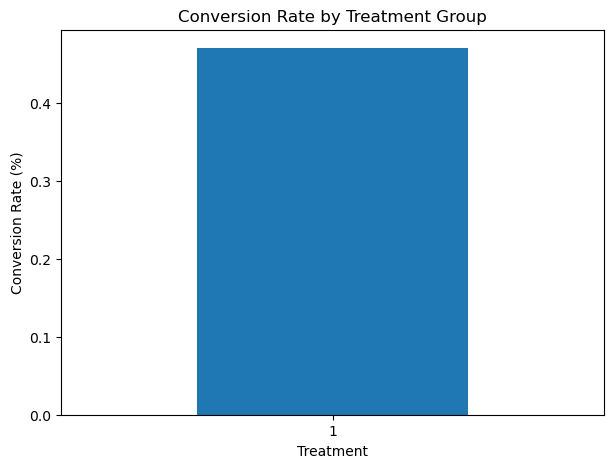

In [26]:
plt.figure(figsize=(7, 5))

conversion_rate_by_treatment.plot(
    kind="bar"
)

plt.title("Conversion Rate by Treatment Group")
plt.xlabel("Treatment")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [27]:
visit_rate_by_treatment = (
    sample_df
    .groupby("treatment")["visit"]
    .mean()
    .mul(100)
)

print("Visit rate by treatment:")
print(visit_rate_by_treatment)

Visit rate by treatment:
treatment
1   2.1000
Name: visit, dtype: float64


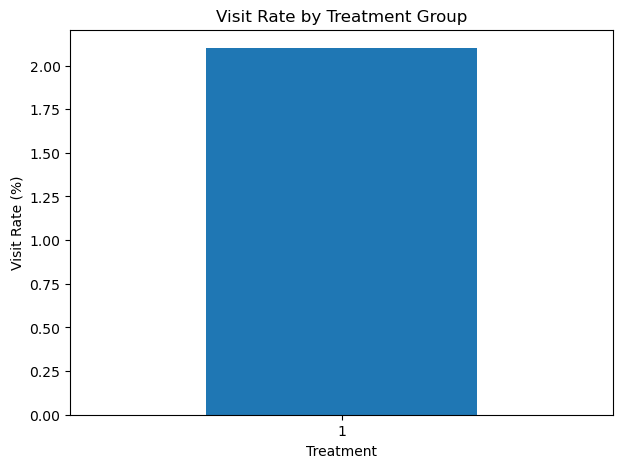

In [28]:
plt.figure(figsize=(7, 5))

visit_rate_by_treatment.plot(
    kind="bar"
)

plt.title("Visit Rate by Treatment Group")
plt.xlabel("Treatment")
plt.ylabel("Visit Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [29]:
exposure_rate_by_treatment = (
    sample_df
    .groupby("treatment")["exposure"]
    .mean()
    .mul(100)
)

print("Exposure rate by treatment:")
print(exposure_rate_by_treatment)

Exposure rate by treatment:
treatment
1   2.4900
Name: exposure, dtype: float64


In [30]:
feature_cols = [f"f{i}" for i in range(12)]

print("Feature columns:")
print(feature_cols)

Feature columns:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


In [31]:
feature_statistics = sample_df[feature_cols].describe().T

feature_statistics

,count,mean,std,min,25%,50%,75%,max
f0,10000.0000,21.2535,4.8403,12.6164,17.9954,22.7445,24.6275,26.7451
f1,10000.0000,10.0666,0.0877,10.0597,10.0597,10.0597,10.0597,13.5798
f2,10000.0000,8.3729,0.2820,8.2144,8.2144,8.2144,8.4128,9.0519
f3,10000.0000,4.3655,1.0976,-4.7984,4.6799,4.6799,4.6799,4.6799
f4,10000.0000,10.3575,0.4522,10.2805,10.2805,10.2805,10.2805,18.7223
f5,10000.0000,4.0368,0.4176,-5.7745,4.1155,4.1155,4.1155,4.1155
f6,10000.0000,-4.2951,4.1756,-24.0935,-6.6993,-3.2821,-1.2882,0.2944
f7,10000.0000,5.0814,1.1608,4.8338,4.8338,4.8338,4.8338,11.9937
f8,10000.0000,3.9538,0.0405,3.6823,3.9554,3.9719,3.9719,3.9719
f9,10000.0000,14.2557,4.3590,13.1901,13.1901,13.1901,13.1901,56.9446


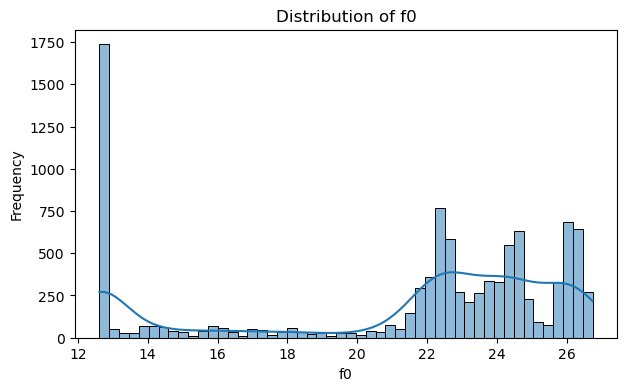

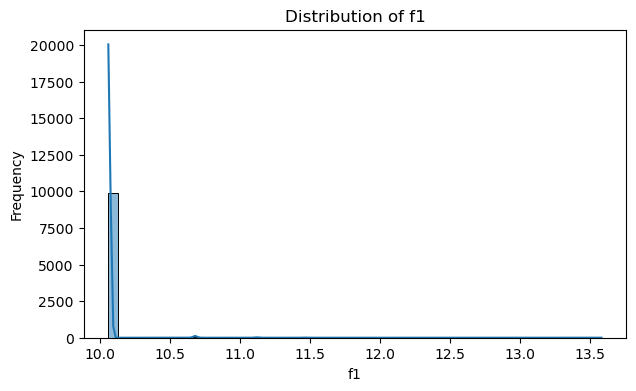

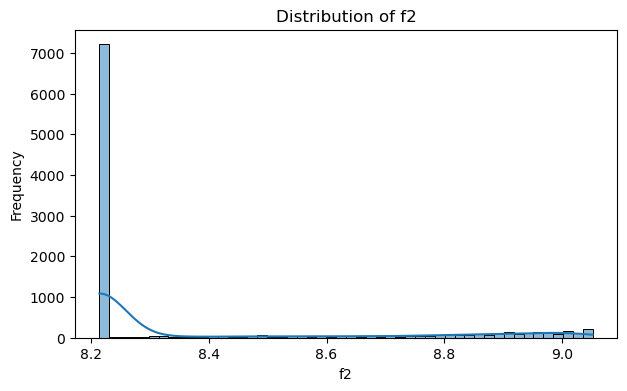

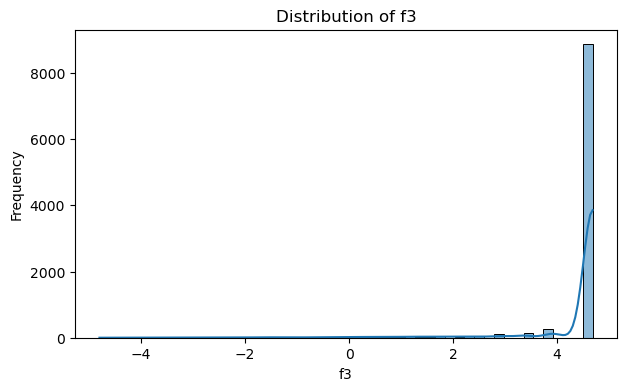

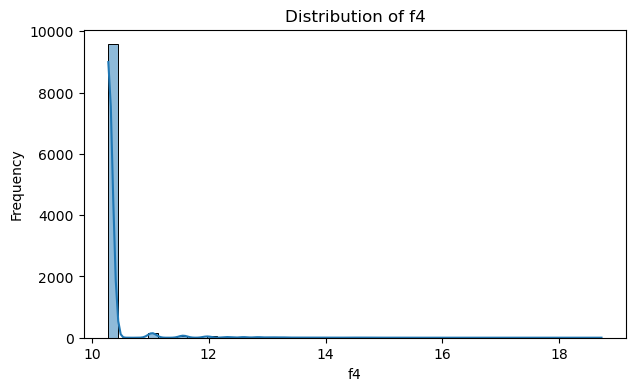

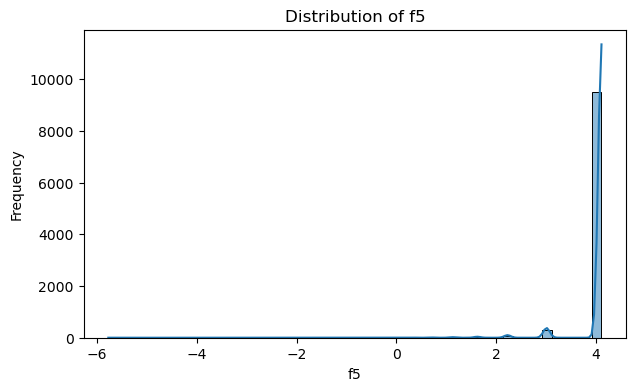

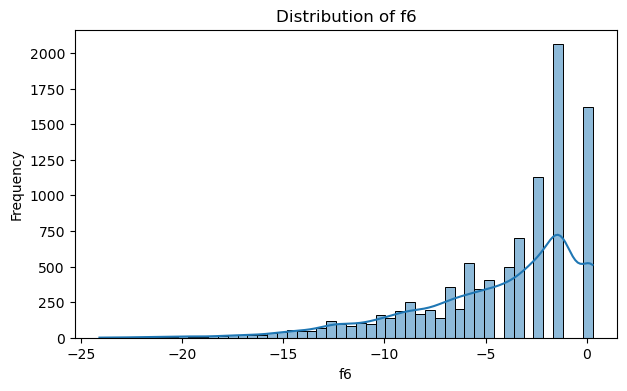

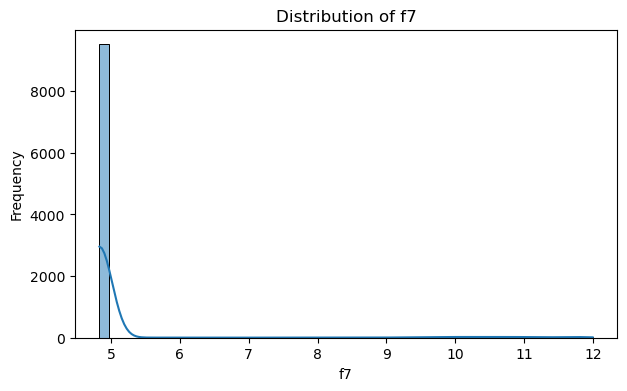

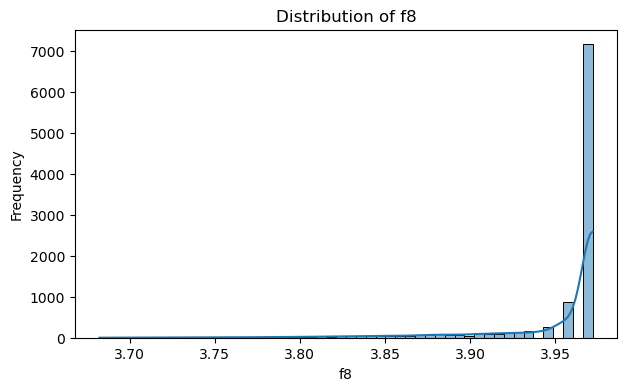

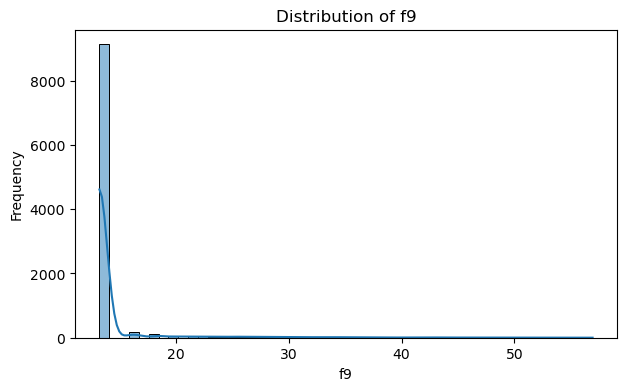

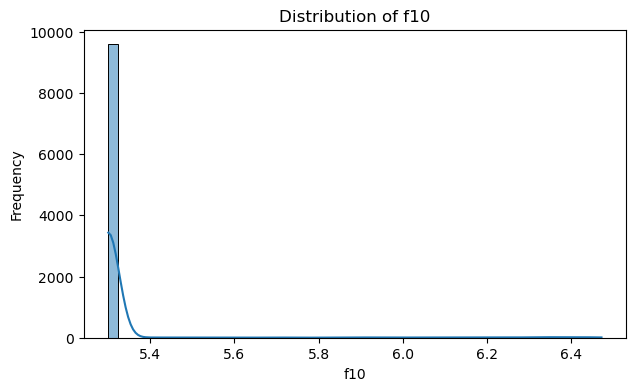

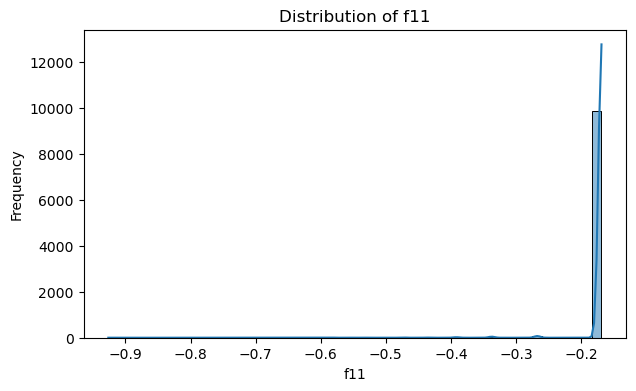

In [32]:
for feature in feature_cols:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        sample_df[feature],
        bins=50,
        kde=True
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()

In [33]:
correlation_matrix = sample_df[feature_cols].corr()

correlation_matrix

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
f0,1.0000,-0.1076,-0.5974,0.3417,-0.1448,0.0745,-0.2531,0.0008,0.3846,-0.2847,-0.1190,0.1325
f1,-0.1076,1.0000,-0.0037,-0.3520,0.3099,-0.5524,-0.1733,0.1191,-0.2461,0.3407,0.0974,-0.3608
f2,-0.5974,-0.0037,1.0000,-0.0094,0.0754,-0.0411,0.1807,0.0495,-0.4734,0.0375,0.1717,0.0127
f3,0.3417,-0.3520,-0.0094,1.0000,-0.3502,0.3388,0.4157,-0.1568,0.3533,-0.4468,-0.2168,0.3338
f4,-0.1448,0.3099,0.0754,-0.3502,1.0000,-0.3528,-0.2617,0.1804,-0.6698,0.6043,0.6371,-0.6736
f5,0.0745,-0.5524,-0.0411,0.3388,-0.3528,1.0000,0.3758,-0.7422,0.3215,-0.2768,-0.2241,0.2663
f6,-0.2531,-0.1733,0.1807,0.4157,-0.2617,0.3758,1.0000,-0.3223,0.1997,-0.1773,-0.2096,0.1560
f7,0.0008,0.1191,0.0495,-0.1568,0.1804,-0.7422,-0.3223,1.0000,-0.2030,0.1155,0.1467,-0.0844
f8,0.3846,-0.2461,-0.4734,0.3533,-0.6698,0.3215,0.1997,-0.2030,1.0000,-0.7016,-0.5957,0.4153
f9,-0.2847,0.3407,0.0375,-0.4468,0.6043,-0.2768,-0.1773,0.1155,-0.7016,1.0000,0.3441,-0.6440


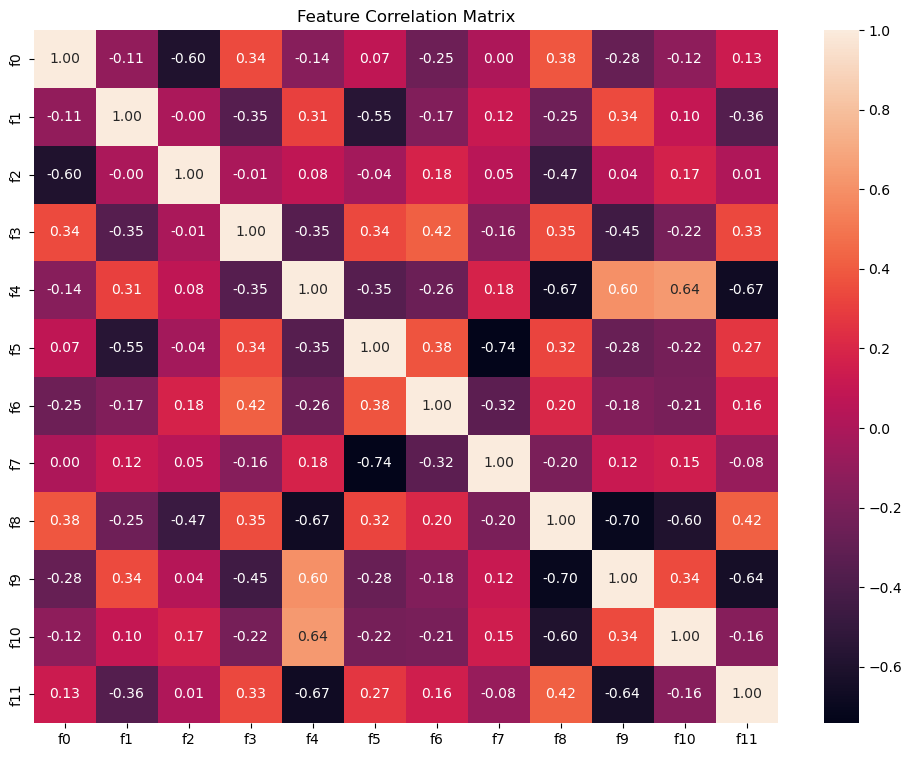

In [34]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [35]:
treatment_summary = (
    sample_df
    .groupby("treatment")
    .agg(
        customers=("treatment", "size"),
        conversion_rate=("conversion", "mean"),
        visit_rate=("visit", "mean"),
        exposure_rate=("exposure", "mean")
    )
)

treatment_summary

,customers,conversion_rate,visit_rate,exposure_rate
treatment,,,,
1,10000,0.0047,0.0210,0.0249


In [36]:
treatment_summary[
    ["conversion_rate", "visit_rate", "exposure_rate"]
] *= 100

treatment_summary

,customers,conversion_rate,visit_rate,exposure_rate
treatment,,,,
1,10000,0.4700,2.1000,2.4900


In [37]:
summary = {
    "Sample rows": len(sample_df),
    "Features": len(feature_cols),
    "Treatment groups": sample_df["treatment"].nunique(),
    "Conversion classes": sample_df["conversion"].nunique(),
    "Visit classes": sample_df["visit"].nunique(),
    "Exposure classes": sample_df["exposure"].nunique(),
    "Total missing values": int(sample_df.isnull().sum().sum())
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Sample rows,10000
1,Features,12
2,Treatment groups,1
3,Conversion classes,2
4,Visit classes,2
5,Exposure classes,2
6,Total missing values,0


## Initial Insights

Based on the initial exploration:

1. The dataset contains anonymized numerical features represented by
   `f0` through `f11`.

2. `treatment` identifies the treatment and control groups and will
   serve as the intervention variable for uplift modeling.

3. `conversion` represents the primary binary outcome that will be
   investigated in the treatment-effect analysis.

4. `visit` provides an additional behavioral outcome that may help
   understand customer response.

5. `exposure` provides information about whether the observation was
   exposed to the relevant intervention.

6. The treatment and control groups will be analyzed separately before
   estimating individual treatment effects.

7. The feature distributions and correlations provide an initial basis
   for subsequent feature engineering and modeling.

8. Differences in observed outcomes between treatment groups should
   not automatically be interpreted as causal effects. Formal causal
   and uplift modeling will be performed in later notebooks.

# Conclusion

This notebook established the initial understanding of the dataset.

We examined:

- Dataset structure
- Feature columns
- Data types
- Missing values
- Dataset size
- Treatment distribution
- Conversion distribution
- Visit distribution
- Exposure distribution
- Treatment-outcome relationships
- Feature distributions
- Feature correlations

The dataset is now sufficiently understood to proceed to the next
stage of the pipeline.

## Next Step

The next notebook, `02_data_quality.ipynb`, will focus on systematic
data-quality validation, including:

- Duplicate detection
- Invalid values
- Data consistency
- Treatment integrity
- Outcome validation
- Feature-level quality checks
- Distribution checks
- Data-quality reporting